# 2026-10-02 · Tutorial: the effective model of the logits in code

This notebook is a guided tour of what was built on the `new-ansatz` branch during the session of 2026-10-01/02. It has four parts:

1. **Recap.** Where the theory stood before the session: the manuscript's signal-closure model, and the extended ansatz of `paper/scratch/extended_ansatz.tex`.
2. **Purpose.** The ideas that motivated the work, and how they were organised into one plan.
3. **What was built.** The features, the conventions they share, and a map of the codebase.
4. **Worked examples.** One section per feature, from loading a run to integrating the effective ODE, all on the run `ansatz_test/run_001`.

Every code cell runs as it is. Figures use `create_fig` from the template.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from tracklab import ExperimentReader

from icl import (
    # runs and matrices
    RunData, ReducedTransformer,
    # the ansatz: order parameters and logits
    ORDER_PARAMS, support_sizes, measure_order_params, ansatz_matrices, ansatz_logits,
    # per-query tables and the canonical layout
    QueryTable, logit_table, logit_blocks, canonical_permutation, cluster_cross_entropy, condition_mask,
    # the sequence variables
    measure_variables, sample_variables, mean_variables,
    # the effective loss and its flow
    EffectiveLoss, trigger_loss, integrate,
    # evaluation probes
    Evaluator, LossMetric, TopKAccuracy, TargetProbMass, OrderParameters, TriggerLogitTable,
    ComposedMatrices, preprocess_batch,
)

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot Configs

In [3]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Part I · Recap: the theory before this session

## I.1 Task, model and unfolded logits

**Task.** Sequences come from a Markov chain on $V$ tokens. There are $K=\rho V$ triggers $\mathcal T$, and each sequence draws its own injective map $\phi:\mathcal T\to\mathcal V\setminus\mathcal T$. A trigger $a$ is always followed by its output $\phi(a)$, and any other token by a uniform draw. The stationary law puts weight $p_T = \frac{1}{V(1+\rho)} = \frac1{V+K}$ on every token except the outputs, which get $2p_T$. In code the triggers are always the tokens $0,\dots,K-1$.

**Model.** A two-layer, single-head, linear-attention transformer with frozen embeddings. Its logits depend on the trained weights only through three composed matrices:
$$
h_{\mu\tau}=\frac{\beta}{L}\sum_{\nu<\mu}\sum_{\sigma<\nu}\bm M_{\nu\sigma}\,\bm Q_{\tau_\mu\tau_\sigma}\,\bm\Gamma_{\tau\tau_\nu},
\qquad \bm M=\tfrac{\bm P^\top \bm W_{QK}^{(1)}\bm P}{\sqrt d},\;\bm Q=\tfrac{\bm E^\top \bm W_{QK}^{(2)}\bm W_{OV}^{(1)}\bm E}{\sqrt d},\;\bm\Gamma=\tfrac{\bm U\bm W_{OV}^{(2)}\bm E}{\sqrt d}.
$$
Each matrix is normalised by $1/\sqrt d$, the convention adopted in `extended_ansatz.tex`. Then no $d$ is left in the logits, and these are the objects every function of the package works with.

**Solvable positions.** Position $\mu$ can be solved in context when its token is a trigger that already appeared earlier in the sequence. Write $\mathcal N_\mu=\ell$ for the number of earlier occurrences. Since the occurrences are close to Poisson, $\ell\sim\text{Poisson}(p_T\mu)$.

## I.2 The manuscript: signal closure

Training makes three components of the matrices grow: the previous-token diagonal $M_{\nu,\nu-1}$, the trigger diagonal $Q_{aa}$ and the non-trigger diagonal $\Gamma_{bb}$. The manuscript keeps only their means $M^{on},Q^{on},\Gamma^{on}$ and builds on them:

- **Logits.** The on-target logit at an induction position has mean $\propto \Omega=\frac1K M^{on}Q^{on}\Gamma^{on}$, and the off-target logits are $\approx 0$.
- **Loss.** An effective loss $\mathcal L^{\rm eff}(\Omega)$ (eq. `effective_loss`) follows from collapsing the logit distribution to these means.
- **Dynamics.** The gradient flow gives three coupled ODEs that grow together, and a learning time $T^*\sim V^2\sqrt L$.

**Its known limits** (manuscript, "Caveats"):
- The on-target distribution is multimodal. It has one mode per $\ell=1,2,\dots$, which the single mean averages away.
- The off-target logits are not a single class. The $K$ trigger logits form their own, lower cluster.
- Every logit has a spread around its mean.
- The trigger positions with $\ell=0$ are put into the constant $\mathcal L^\infty$, even though their loss depends on the parameters once triggers are recognised.

## I.3 The extended ansatz (`extended_ansatz.tex`, 2026-09-30)

The extended ansatz adds one component per matrix:
$$
\bm M_{\nu\sigma}=M^{on}\delta_{\sigma,\nu-1}+M^{off}\mathbb 1\{\sigma\le\nu-2\},\quad
\bm Q_{ac}=\mathbb 1\{a\in\mathcal T\}\big[Q^{on}\delta_{ac}+Q^T(1-\delta_{ac})\big],\quad
\bm\Gamma_{\tau b}=\Gamma^{on}\delta_{\tau b}\mathbb 1\{\tau\notin\mathcal T\}+\Gamma^T\mathbb 1\{\tau\in\mathcal T\}.
$$
Each order parameter is the **mean of its matrix over its support**. For example, $M^{off}$ is the mean of $\bm M$ below the sub-diagonal, and $\Gamma^T$ is the mean of the trigger rows of $\bm\Gamma$. The non-trigger rows of $\bm Q$ are set to zero, so every logit at a non-trigger query is exactly zero.

**Logit classes.** At a trigger query $\tau_\mu=a$:
- the target $\phi(a)$ has one logit, $h^{on}$;
- the $K$ trigger logits are **exactly equal**, $h^{\mathcal T}$;
- each of the $V-K-1$ other non-trigger tokens $b$ has **its own** logit, $h^{off}_b$, because it depends on how often and where $b$ occurs in the context.

With $\Delta Q=Q^{on}-Q^T$ these are (eq. `logit_classes_explicit`)
$$
\begin{aligned}
h^{on}_\mu&=\tfrac\beta L\Gamma^{on}\big[M^{on}Q^{on}\mathcal N+M^{on}Q^T\mathcal F+M^{off}Q^T\mathcal W+M^{off}\Delta Q\,\mathcal P\big],\\
h^{\mathcal T}_\mu&=\tfrac\beta L\Gamma^{T}\big[M^{on}Q^T(\mu-2)+M^{off}Q^T\tfrac{(\mu-2)(\mu-3)}2+M^{on}\Delta Q\,\mathcal N+M^{off}\Delta Q\,\mathcal R\big],\\
h^{off}_{\mu,b}&=\tfrac\beta L\Gamma^{on}\big[M^{on}Q^T\overline{\mathcal U}_b+M^{off}Q^T\overline{\mathcal W}_b+M^{off}\Delta Q\,\overline{\mathcal P}_b\big].
\end{aligned}
$$

**The counting variables of Table 1.** These are properties of the sequence, not of the model:

| Variable | Meaning |
|---|---|
| $\mathcal N$ | earlier occurrences of $a$ (this is $\ell$) |
| $\mathcal F$ | free occurrences of $\phi(a)$, i.e. not right after an $a$ |
| $\mathcal R$ | for each earlier $a$, the number of keys at distance $\ge2$ after it |
| $\mathcal W$ | sum of $\nu-2$ over the keys holding $\phi(a)$ |
| $\mathcal P$ | pairs $(a,\dots,\phi(a))$ at distance $\ge 2$ |
| $\overline{\mathcal U}_b,\overline{\mathcal W}_b,\overline{\mathcal P}_b$ | the same three counts for each non-target token $b$ |

**Their law at fixed $\ell$ (Table 2).** The earlier $a$'s sit at $x_k\sim U(0,1)$. The free targets are $\text{Poisson}(m)$, with $m=p_T\mu$, at $y_j\sim U(0,1)$. Each non-target token occurs $\text{Poisson}(r_b)$ times, with $r_b=2m$ if it is the output of another trigger and $m$ otherwise. The table gives the mean and variance of every variable, and the covariances follow (shared $x_k$, Campbell's formula).

**Sampling protocol.** Draw the latent quantities ($x$, then $f$ and $y$, then $c_b$ and $z$), compute the variables, plug them into the formulas. The counts can be independent Poissons, or one multinomial over the available keys; the multinomial keeps the weak anti-correlation between counts.

**What the ansatz leaves out:** the *background*, i.e. everything in the matrices outside these six numbers. It adds a spread to every logit.

# Part II · Purpose of this session

The goal was to **turn the extended ansatz into code that can be checked against training, and then use it for dynamics**. The starting ideas were:

1. **Check the variables.** Measure the Table 1 variables on real sequences and compare their distributions with Table 2.
2. **Sample logit vectors.** Implement the sampling protocol so that it produces whole vectors $\bm h_\mu\in\mathbb R^V$, conditioned on $(\mu,\ell)$, in a fixed layout: triggers first, then the outputs of the other triggers, the remaining tokens, and the target last.
3. **Compare with the trained model.** Get the model's logits in the same layout, split by $\ell$ and by $\mu$, so the two can be compared directly. This replaces the nested on/off pickles, which also had no $\ell$ split.
4. **Effective loss.** Evaluate the population loss of the effective model from the order parameters, either at the mean logits or by Monte Carlo over the sampled ones.
5. **Effective dynamics.** Get the gradient of that loss with respect to the order parameters and integrate the flow. The rates, i.e. the Jacobian of the projection, come from your own derivation.

Three more needs came up along the way:

- **Matrices as a first-class object.** One convention for $\bm M,\bm Q,\bm\Gamma$, one file per step on disk, and one object (`RunData`) to read a run back and rebuild its model.
- **The $\ell=0$ queries.** The old evaluation filtered the test batch and kept only induction-possible positions. That biased the logged loss and dropped the $\ell=0$ queries entirely. Positions are now selected by *trigger* and *$\ell$*.
- **Extensibility.** Adding or removing an order parameter must not require touching the loss, the flow or the probes.

The design principle throughout was to do *as much as necessary but as little as possible*. Everything is plain torch, so it runs on the GPU and is differentiable. All the ansatz-specific code lives in two files, and every feature has tests.

# Part III · What was built

## III.1 Conventions shared by everything

| Convention | Meaning |
|---|---|
| Positions $\mu$ | Counted from 1 like the paper. Code position `p` is $\mu=p+1$, and the keys are $\nu=2,\dots,\mu-1$. |
| $\ell$ | Earlier occurrences of the query token, i.e. `counts - 1`. |
| Rows | One row per **trigger query**, for every $\ell\ge0$. At non-trigger queries the ansatz logits are 0 and the loss is $\log V$. |
| Canonical layout | Columns `[0, K)` triggers · `[K, 2K-1)` outputs of the other triggers (ordered by trigger) · `[2K-1, V-1)` the rest (by token id) · `V-1` **the target**. So the target is always the last column. |
| Matrices | The plain dict `{"M", "Q", "G"}`, normalised by $\sqrt d$, with M masked like layer 1. |
| Order parameters | A dict `{name: value}` over the names of `ORDER_PARAMS`. A missing name counts as 0. |

## III.2 Features, by module

| Module | Feature | What it is for |
|---|---|---|
| `model.py`, `reduced.py` | `model.matrices()`; `ReducedTransformer.from_matrices(mats, model_args)` | One matrix convention; the exact model of any `lin_attn` run, rebuilt from its saved matrices |
| `evaluation/artifacts.py` | `ComposedMatrices` (one `matrices_step_N.pkl` per step); `TriggerLogitTable` (`logits/table_step_N.pkl`) | What a training run saves |
| `runs.py` | `RunData`: `.config`, `.metrics`, `.steps`, `.load`, `.matrices`, `.model`, `.batch`, `.order_params`, `.logit_table` | One entry point for analysing a run |
| `theory/query_table.py` | `QueryTable` (`select`, `groups`, …), `logit_blocks`, `canonical_permutation`, `logit_table`, `cluster_cross_entropy`, `condition_mask` | The empirical side: the model's logits per trigger query, in the canonical layout (idea 3) |
| `theory/ansatz.py` | `ORDER_PARAMS` registry, `measure_order_params`, `ansatz_matrices`, `support_sizes`, `ansatz_logits` | The ansatz itself: its order parameters and eq. `logit_classes_explicit` |
| `theory/variables.py` | `measure_variables`, `sample_variables`, `mean_variables` | The Table 1 variables: measured (idea 1), sampled (idea 2), averaged (Table 2) |
| `theory/effective.py` | `EffectiveLoss` (`mean` / `mc`), `trigger_loss`, `integrate` | The effective loss and its gradient (idea 4), and the flow (idea 5) |
| `evaluation/scalars.py`, `evaluator.py`, `batch.py` | `LossMetric(positions, ell)`, in-context `TopKAccuracy` / `TargetProbMass`, `OrderParameters`; unfiltered test batch | Logging during training, with $\ell=0$ included |

## III.3 Map of the codebase

New or changed pieces are marked `*`. An arrow means "imports / uses".

```
                           ┌──────────────────────── icl ────────────────────────┐
  data.py ───────────────────────────────▶ theory/query_table.py *
  generate_icl_batch (+ "V" *)              QueryTable · logit_blocks · canonical_permutation
  occurrence_counts                         trigger_queries · logit_table · cluster_cross_entropy
                                            condition_mask / check_condition
                                                 │
                     ┌───────────────────────────┼───────────────────────────┐
                     ▼                           ▼                           ▼
            theory/ansatz.py *          theory/variables.py *        theory/effective.py *
            ORDER_PARAMS registry       measure_variables            EffectiveLoss (mean | mc)
            measure_order_params        sample_variables             trigger_loss
            ansatz_matrices             mean_variables               integrate (solve_ivp)
            support_sizes                    │                        ▲   uses ansatz + variables
            ansatz_logits ◀──────────────────┘────────────────────────┘
                     ▲
   ┌─────────────────┴───────────────── evaluation/ * ──────────────────────────────┐
   │ batch.py      preprocess_batch (no filter, no mask)                            │
   │ evaluator.py  EvalContext: is_trigger, ell, trigger_logits · Evaluator         │
   │ scalars.py    LossMetric(positions, ell) · TopKAccuracy / TargetProbMass (ℓ≥1) │
   │               OrderParameters (every entry of ORDER_PARAMS)                    │
   │ artifacts.py  ComposedMatrices · TriggerLogitTable · AttentionMaps             │
   └────────────────────────────────────────────────────────────────────────────────┘
        ▲ probes                                                   │ files on disk
  model.py  MinimalTransformer.matrices() *                        ▼
  reduced.py ReducedTransformer.matrices() / .from_matrices() *   data/<exp>/run_NNN/
        ▲                                                          artifacts/matrices/matrices_step_N.pkl
        └────────────── runs.py RunData * ◀────────────────────────artifacts/logits/table_step_N.pkl
                         (tracklab ExperimentReader inside)        metrics.jsonl, config.json
  scripts/train.py, scripts/launcher.py: build the Evaluator with these probes and train.
```

**The rule that keeps it extensible.** Only `theory/ansatz.py` and `theory/variables.py` know the ansatz. The loss, the flow, the probes and `RunData` are written against the registry and the `QueryTable` columns.

## III.4 The three levels of comparison

On one batch of sequences, the same rows (trigger queries) can be filled in three ways:

```
 A  logit_table(run.model(step), batch)                                  the trained model's logits
 B  ansatz_logits(measure_variables(batch), run.order_params(step), …)   the ansatz on the same sequences
 C  ansatz_logits(sample_variables(mu, ell, …), run.order_params(step), …)   the ansatz on sampled variables
```

- **B − A** is the background. B equals the model run on `ansatz_matrices(order_params)` to ~1e-12; `tests/test_theory.py` checks this.
- **C vs B** measures the approximations in the variables' law (Poisson counts, uniform positions, $\mu\gg1$).
- **`EffectiveLoss`** is the population loss built from C (or from its means), so it compares with the loss of A.

## III.5 Tests

There are 68 tests in `tests/`. The new files are `test_runs.py`, `test_theory.py` (exactness), `test_evaluation.py`, `test_sampler.py` (Table 2 moments), `test_effective_loss.py` and `test_flow.py`.

# Part IV · Worked examples

## 1. Reading a run: `RunData`

`RunData(experiment, run_id, base_dir)` replaces the manual `ExperimentReader` plumbing: listing artifacts, filtering by name and step, rebuilding configs.

`ansatz_test/run_001` was trained with the reduced backend: $V=128$, $L=256$, $K=25$, $d=8000$, 3000 SGD steps. The induction head forms between steps ~1500 and ~2000.

In [4]:
experiment_name, run_id, base_dir = "ansatz_test", "run_001", "../data"
run = RunData(experiment_name, run_id, base_dir=base_dir)      # or RunData.last(experiment_name, base_dir=base_dir)

config = run.config                                            # typed TrainerArgs, exactly as saved by the run
L, V, K = config.model_args.seq_len, config.model_args.vocab_size, config.data_args.K
beta = config.model_args.beta
device = "cuda" if torch.cuda.is_available() else "cpu"

print(run, f"| V={V} L={L} K={K} beta={beta} d={config.model_args.d_model} backend={config.model_args.backend}")
print("steps with matrices:", run.steps("matrices"))
print("steps with logit tables:", run.steps("logits"))
run.metrics.head()                                             # wide: one row per evaluated step

RunData('ansatz_test', 'run_001') | V=128 L=256 K=25 beta=0.25 d=8000 backend=reduced
steps with matrices: [0, 333, 667, 1000, 1333, 1667, 2000, 2333, 2667, 3000]
steps with logit tables: [0, 333, 667, 1000, 1333, 1667, 2000, 2333, 2667, 3000]


metric,G_T,G_on,M_off,M_on,Q_T,Q_on,loss,top1_accuracy
step,,,,,,,,
0,-0.000122,0.085224,0.004405,0.023002,-0.003008,-0.203489,4.856716,0.009801
61,-0.000507,0.071990,0.003934,0.022822,-0.003293,-0.192859,4.854651,0.009984
122,-0.001092,0.067335,0.002947,0.021368,-0.003747,-0.191388,4.853763,0.009618
184,-0.000583,0.057499,0.003039,0.019092,-0.003869,-0.178206,4.853274,0.009618
245,-0.000338,0.053986,0.002646,0.015301,-0.004947,-0.170615,4.852976,0.009526


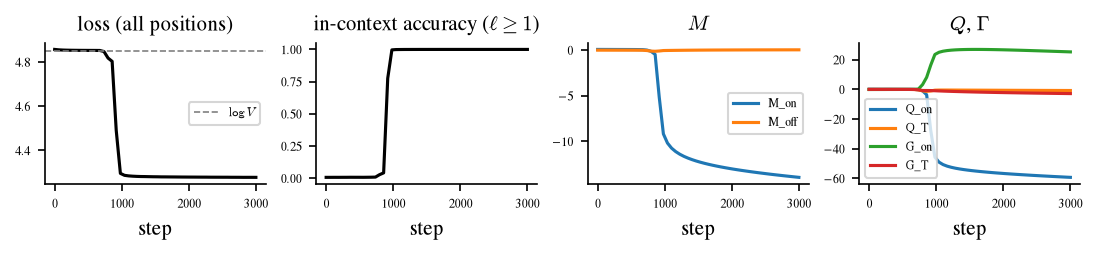

In [6]:
metrics = run.metrics
fig, axes = create_fig(ncols=4, size='double', h=0.22, sharex=True)
axes[0].plot(metrics.index, metrics["loss"], color="k")
axes[0].axhline(np.log(V), ls="--", lw=0.8, color="gray", label=r"$\log V$")
axes[0].set_title("loss (all positions)"); axes[0].legend()
axes[1].plot(metrics.index, metrics["top1_accuracy"], color="k"); axes[1].set_title(r"in-context accuracy ($\ell\geq1$)")
for name in ("M_on", "M_off"):
    axes[2].plot(metrics.index, metrics[name], label=name)
for name in ("Q_on", "Q_T", "G_on", "G_T"):
    axes[3].plot(metrics.index, metrics[name], label=name)
axes[2].set_title(r"$M$"); axes[3].set_title(r"$Q$, $\Gamma$")
for ax in axes:
    ax.set_xlabel("step")
axes[2].legend(); axes[3].legend()
plt.show()

**Matrices.** `run.matrices(step)` returns `{"M", "Q", "G"}` as torch tensors. `step` can be an int, `"first"` or `"last"`. On disk this is one pickle per step, `matrices/matrices_step_N.pkl`, holding a plain dict of numpy arrays. So `run.reader`, the plain TrackLab reader, can load it without `icl`.

 step     name                   file   type
 2667 matrices matrices_step_2667.pkl pickle
 3000 matrices matrices_step_3000.pkl pickle
{'M': (512, 512), 'Q': (128, 128), 'G': (128, 128)}


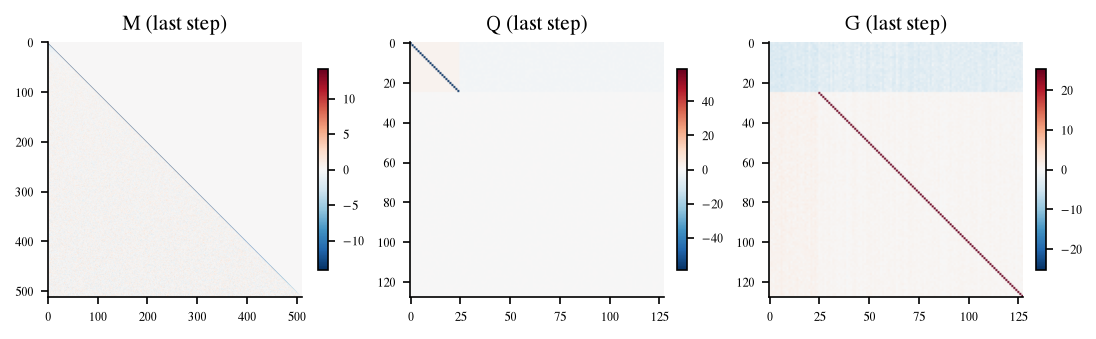

In [28]:
matrices = run.matrices("last")
fig, axes = create_fig(ncols=3, size='double', h=0.3, sharex=False)
for ax, (name, matrix) in zip(axes, matrices.items()):
    limit = matrix.abs().flatten().kthvalue(int(0.999 * matrix.numel())).values.item()
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(f"{name} (last step)"); fig.colorbar(image, ax=ax, shrink=0.7)

# the same file with tracklab alone
index = run.reader.list_artifacts(run.run_id, "matrices")
raw = run.reader.load_artifact(run.run_id, index["file"].iloc[-1], "matrices")
print(index.tail(2).to_string(index=False)); print({name: array.shape for name, array in raw.items()})

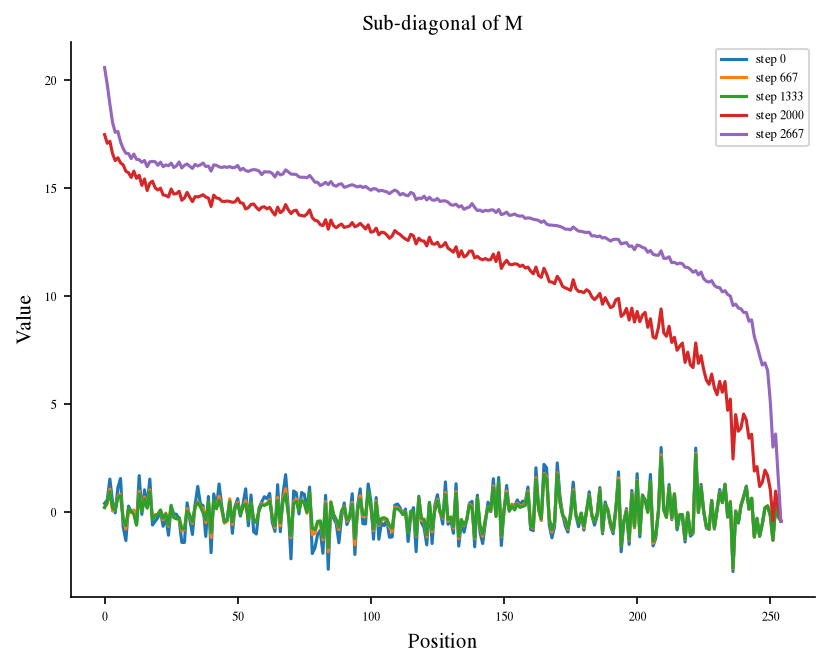

256

In [28]:
steps = run.steps("matrices")
for step in steps[::2]:
    matrices = run.matrices(step)
    sub_diag = np.array([matrices['M'].numpy()[j,j-1] for j in range(1, matrices['M'].shape[0])])
    plt.plot((-sub_diag), label=f"step {step}")

# plt.plot(3700*np.arange(L)/L)

plt.legend()
plt.title("Sub-diagonal of M"); plt.xlabel("Position"); plt.ylabel("Value"); plt.show()


L

In [34]:
from scipy.special import lambertw

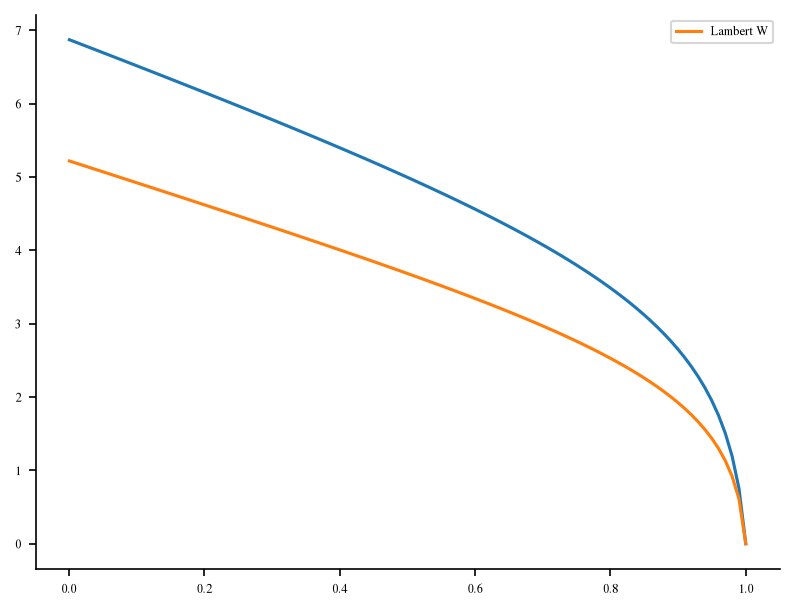

In [37]:
L,V,rho = 512, 124, 0.2
lam = L/((1+rho)*V)
x = np.linspace(1e-3,1,100)
S = np.exp(-lam*x) - np.exp(-lam)
C = 1000.0
A = np.log(1+C*S)

A1 = lambertw(C*S)
plt.plot(x, A)
plt.plot(x, A1.real, label="Lambert W")
plt.legend()

**Model and batches.**
- `run.model(step)` is a `ReducedTransformer` built with `from_matrices`. Its forward pass is exactly the trained network's, whatever backend and $d$ the run used. Its Gram matrices are the identity, so training it further would follow the $d=\infty$ dynamics.
- `run.batch(n, seed)` draws a fresh, **unfiltered** batch of the run's task, so every analysis below uses unbiased statistics.
- `run.load(group, name, step)` reads any other artifact.

In [10]:
model = run.model("last", device=device)
batch = run.batch(8192, seed=0)                 # dict: sequence (n, L+1), output_set (n, K), K, V, counts, is_trigg
with torch.no_grad():
    logits = model(batch["sequence"][:16, :-1].to(device))
print(type(model).__name__, "| logits", tuple(logits.shape), "| batch keys:", list(batch))

ReducedTransformer | logits (16, 512, 128) | batch keys: ['sequence', 'K', 'V', 'output_set', 'counts', 'is_trigg']


## 2. Order parameters: the `ORDER_PARAMS` registry

Each order parameter is declared **once**, as `name: (matrix, support_function)`, in `theory/ansatz.py`. From that one declaration you get:

- `measure_order_params(matrices, K)`: the mean of each matrix over each support. The `OrderParameters` probe logs this during training, and `run.order_params(step)` computes it from saved matrices.
- `ansatz_matrices(order_params, L, V, K)`: the matrices that are exactly of ansatz form. This is the inverse of the line above.
- `support_sizes(L, V, K)`: the number of entries $n_i$ each parameter averages over. Use it to cross-check your analytical rates.

The supports, drawn for a tiny $L=8$, $V=10$, $K=2$:

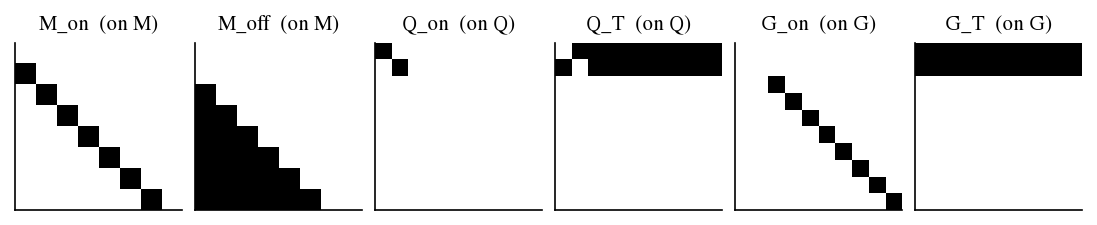

In [11]:
fig, axes = create_fig(ncols=len(ORDER_PARAMS), size='double', h=0.2, sharex=False, sharey=False)
for ax, (name, (matrix_name, support)) in zip(axes, ORDER_PARAMS.items()):
    ax.imshow(support(8, 10, 2), cmap="Greys", vmin=0, vmax=1)
    ax.set_title(f"{name}  (on {matrix_name})"); ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [12]:
order_params = run.order_params("last")
pd.DataFrame({"matrix": {name: matrix for name, (matrix, _) in ORDER_PARAMS.items()},
              "support size n_i": support_sizes(L, V, K),
              "from saved matrices": order_params,
              "logged metric": run.metrics.iloc[-1][list(ORDER_PARAMS)]})

,matrix,support size n_i,from saved matrices,logged metric
M_on,M,511,-13.950486,-13.950486
M_off,M,130305,0.035549,0.035549
Q_on,Q,25,-59.235138,-59.235138
Q_T,Q,3175,-0.766512,-0.766512
G_on,G,103,25.233387,25.233387
G_T,G,3200,-2.837767,-2.837767


`ansatz_matrices` turns the six numbers back into matrices. Comparing them with the real ones shows what the background is: everything the ansatz averages away.

round trip: True


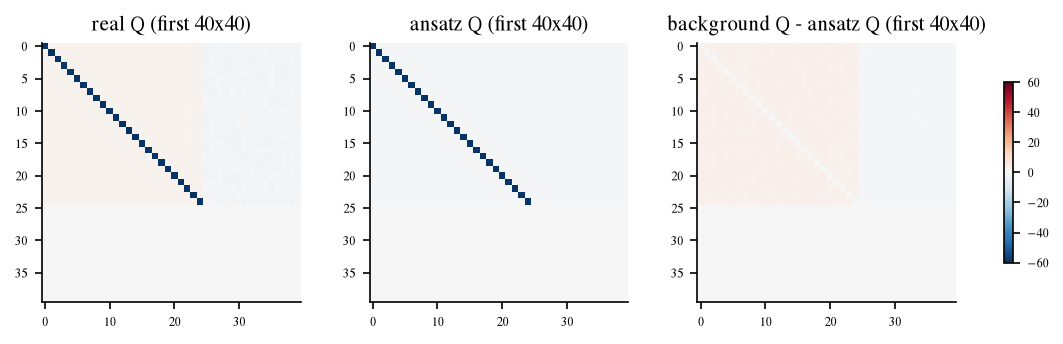

In [13]:
projected = ansatz_matrices(order_params, L, V, K)
print("round trip:", all(abs(measure_order_params(projected, K)[name] - value) < 1e-9 for name, value in order_params.items()))
fig, axes = create_fig(ncols=3, size='double', h=0.3, sharex=False)
real_Q = matrices["Q"].double()
limit = real_Q.abs().max().item()
for ax, (title, matrix) in zip(axes, [("real Q", real_Q), ("ansatz Q", projected["Q"]), ("background Q - ansatz Q", real_Q - projected["Q"])]):
    image = ax.imshow(matrix[:40, :40], cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title + " (first 40x40)")
fig.colorbar(image, ax=axes, shrink=0.7)
plt.show()

## 3. The model's logits per trigger query: `QueryTable` and `logit_table`

`logit_table(model, batch, mus=None, chunk=None)`:
1. runs the model;
2. keeps **every trigger query** ($\ell\ge0$) at the chosen positions $\mu$ (all of them if `mus=None`);
3. reorders each logit vector into the canonical layout.

The result is a `QueryTable`: a dict of tensor columns with one row per query.

| Column | Shape | Content |
|---|---|---|
| `logits` | (n, V) | canonical layout |
| `mu` | (n,) | position, counted from 1 |
| `ell` | (n,) | earlier occurrences of the trigger |
| `sequence_index` | (n,) | row of the batch |
| `K` | int | metadata |

In [14]:
# mus = [64, 128, 192, 256]
mus = [256, 512]
model_table = logit_table(model, batch, mus=mus, chunk=1024)
print("rows:", model_table.num_rows)
print({name: (tuple(value.shape) if torch.is_tensor(value) else value) for name, value in model_table.items()})

blocks = logit_blocks(K, V)          # column slices of the canonical layout
blocks

rows: 2676
{'logits': (2676, 128), 'mu': (2676,), 'ell': (2676,), 'sequence_index': (2676,), 'K': 25}


{'triggers': slice(0, 25, None),
 'other_outputs': slice(25, 49, None),
 'rest': slice(49, 127, None),
 'target': slice(127, 128, None),
 'non_target': slice(25, 127, None)}

**The canonical layout on one row.** `canonical_permutation(query_tokens, output_sets, K, V)` gives, for each row, the token shown at each slot. `logit_table` applies it with `gather`.

In [15]:
row = 0
sequence_index, mu = model_table["sequence_index"][row].item(), model_table["mu"][row].item()
query = batch["sequence"][sequence_index, mu - 1].item()
outputs = batch["output_set"][sequence_index]
permutation = canonical_permutation(torch.tensor([query]), outputs[None], K, V)[0]
print(f"query trigger a = {query}, its target phi(a) = {outputs[query].item()}")
for block, columns in blocks.items():
    if block != "non_target":
        print(f"{block:14s} slots {columns.start:3d}..{columns.stop - 1:3d} hold tokens {permutation[columns].tolist()[:8]}{' ...' if columns.stop - columns.start > 8 else ''}")

query trigger a = 5, its target phi(a) = 100
triggers       slots   0.. 24 hold tokens [0, 1, 2, 3, 4, 5, 6, 7] ...
other_outputs  slots  25.. 48 hold tokens [64, 62, 35, 94, 92, 112, 56, 104] ...
rest           slots  49..126 hold tokens [25, 26, 27, 28, 29, 30, 31, 32] ...
target         slots 127..127 hold tokens [100]


**Selecting clusters.**
- `select(column=condition, ...)` keeps the rows matching **every** condition. A condition is an int, a list, or `">=k"`.
- `groups(*columns)` iterates over every distinct combination.
- `to_numpy` / `from_numpy` round-trip a table through a plain dict, which is what the probe pickles. `concatenate` stacks tables.

In [16]:
def as_frame(table):
    # the one-dimensional columns of a QueryTable as a DataFrame (for display)
    return pd.DataFrame({name: value.cpu().numpy() for name, value in table.items()
                         if torch.is_tensor(value) and value.dim() == 1})

print(model_table.select(mu=256, ell=2).num_rows, "rows at mu=256, ell=2;",
      model_table.select(mu=256, ell=">=1").num_rows, "with ell>=1;",
      model_table.select(mu=[192, 256], ell=[0, 1]).num_rows, "at mu in {192,256} and ell in {0,1}")
counts = pd.DataFrame([{"mu": mu, "ell": ell, "rows": cluster.num_rows} for (mu, ell), cluster in model_table.groups("mu", "ell")])
counts.pivot(index="ell", columns="mu", values="rows").fillna(0).astype(int)

363 rows at mu=256, ell=2; 1100 with ell>=1; 653 at mu in {192,256} and ell in {0,1}


mu,256,512
ell,,
0,233,45
1,420,154
2,363,264
3,210,283
4,61,251
5,38,183
6,5,92
7,3,41
8,0,22


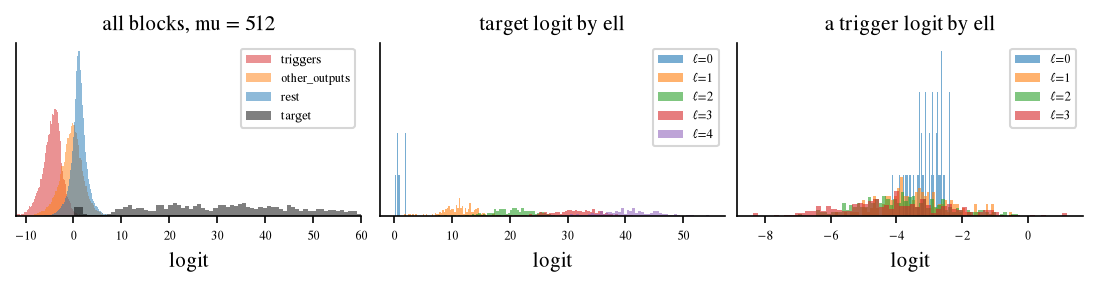

In [17]:
fig, axes = create_fig(ncols=3, size='double', h=0.25, sharex=False)
at_last = model_table.select(mu=L)
for block, color in (("triggers", "C3"), ("other_outputs", "C1"), ("rest", "C0"), ("target", "k")):
    axes[0].hist(at_last["logits"][:, blocks[block]].flatten().numpy(), bins=120, density=True, alpha=0.5,
                 color=color, label=block, histtype="stepfilled")
axes[0].set_title(f"all blocks, mu = {L}"); axes[0].legend(); axes[0].set_xlim(-12, 60)
for (ell,), cluster in at_last.groups("ell"):
    if ell <= 4:
        axes[1].hist(cluster["logits"][:, -1].numpy(), bins=60, density=True, alpha=0.6, label=fr"$\ell$={ell}")
axes[1].set_title("target logit by ell"); axes[1].legend()
for (ell,), cluster in at_last.groups("ell"):
    if ell <= 3:
        axes[2].hist(cluster["logits"][:, blocks["triggers"]][:, 0].numpy(), bins=60, density=True, alpha=0.6, label=fr"$\ell$={ell}")
axes[2].set_title("a trigger logit by ell"); axes[2].legend()
for ax in axes:
    ax.set_xlabel("logit"); ax.set_yticks([])
plt.show()

**Loss per cluster.** `cluster_cross_entropy(table)` returns one row per $(\mu,\ell)$ with `count` and the mean `cross_entropy`, i.e. `logsumexp(logits) - logits[:, -1]` (the target is the last column). `EffectiveLoss` produces the same table from the effective model (Section 7).

In [18]:
model_clusters = cluster_cross_entropy(model_table)
frame = as_frame(model_clusters)
frame[frame["ell"] <= 4].pivot(index="ell", columns="mu", values="cross_entropy").round(4)

mu,256,512
ell,,
0,4.5938,4.6638
1,0.0015,0.1413
2,0.0000,0.0010
3,0.0000,0.0000
4,0.0000,0.0000


In [24]:
saved = QueryTable.from_numpy(model_table.select(mu=512).to_numpy())     # what the probe pickles, and back
both = QueryTable.concatenate([model_table.select(mu=64), model_table.select(mu=128)])
print(saved.num_rows, both.num_rows, sorted(set(both["mu"].tolist())))

1343 0 []


## 4. The measured variables, and the ansatz on the same sequences (levels A vs B)

`measure_variables(batch, mus)` computes the Table 1 variables **exactly**: finite $\mu$, integer positions, no approximation. Its rows line up one to one with `logit_table(model, batch, mus)` on the same batch.

| Column | Shape | Content |
|---|---|---|
| `N`, `F`, `R`, `W`, `P` | (n,) | the target and trigger variables |
| `U_bar`, `W_bar`, `P_bar` | (n, V-K-1) | one column per non-target token, in the order of the `non_target` block: first the $K-1$ outputs of other triggers, then the rest |

In [20]:
variables = measure_variables(batch, mus=mus)
assert torch.equal(variables["mu"], model_table["mu"]) and torch.equal(variables["ell"], model_table["ell"])
print({name: (tuple(value.shape) if torch.is_tensor(value) else value) for name, value in variables.items()})
as_frame(variables).head()

{'mu': (2676,), 'ell': (2676,), 'N': (2676,), 'F': (2676,), 'R': (2676,), 'W': (2676,), 'P': (2676,), 'U_bar': (2676, 102), 'W_bar': (2676, 102), 'P_bar': (2676, 102), 'K': 25}


,mu,ell,N,F,R,W,P
0,256,0,0.0,4.0,0.0,313.0,0.0
1,512,4,4.0,3.0,1163.0,1462.0,12.0
2,256,0,0.0,3.0,0.0,519.0,0.0
3,512,4,4.0,2.0,1358.0,1529.0,14.0
4,256,3,3.0,2.0,287.0,788.0,6.0


**Exactness.** If the matrices are exactly of ansatz form, the formula and the network must agree to rounding. This is the safety net when the ansatz is extended: `tests/test_theory.py` checks it for random order parameters.

In [21]:
ansatz_model = ReducedTransformer.from_matrices(ansatz_matrices(order_params, L, V, K), config.model_args)
network_on_ansatz = logit_table(ansatz_model, batch, mus=mus, chunk=1024)["logits"]
formula = ansatz_logits(variables, order_params, beta, L)            # (n, V), canonical layout
print("max |network on ansatz matrices - ansatz formula| =", (network_on_ansatz - formula).abs().max().item())

max |network on ansatz matrices - ansatz formula| = 5.400124791776761e-13


**Background (A − B).** Now compare the formula with the *trained* model, which has the real matrices.

,real mean,real std,ansatz mean,ansatz std,background std
block,,,,,
triggers,-3.887,1.756,-3.942,1.029,1.491
other_outputs,-0.264,1.946,0.125,0.245,1.952
rest,1.003,1.289,0.062,0.153,1.284
target,27.716,18.354,25.656,17.785,4.220


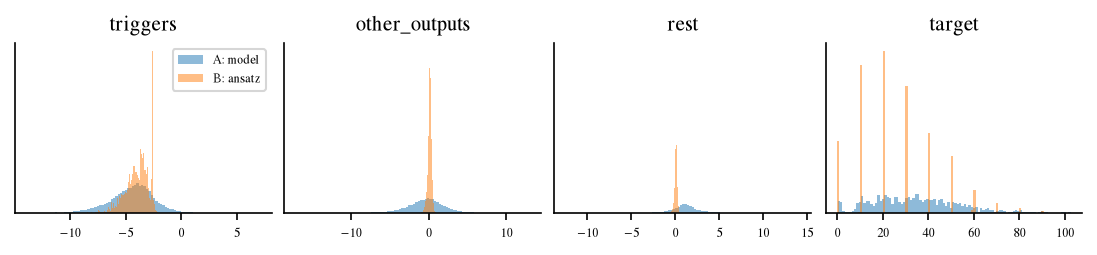

In [27]:
background = model_table["logits"] - formula
summary = []
for block in ("triggers", "other_outputs", "rest", "target"):
    real, ansatz = model_table["logits"][:, blocks[block]], formula[:, blocks[block]]
    summary.append({"block": block, "real mean": real.mean().item(), "real std": real.std().item(),
                    "ansatz mean": ansatz.mean().item(), "ansatz std": ansatz.std().item(),
                    "background std": background[:, blocks[block]].std().item()})
display(pd.DataFrame(summary).set_index("block").round(3))

fig, axes = create_fig(ncols=4, size='double', h=0.22, sharex=False)
for ax, block in zip(axes, ("triggers", "other_outputs", "rest", "target")):
    ax.hist(model_table.select(mu=512)["logits"][:, blocks[block]].flatten().numpy(), bins=100, density=True, alpha=0.5, label="A: model")
    ax.hist(formula[:, blocks[block]].flatten().numpy(), bins=100, density=True, alpha=0.5, label="B: ansatz")
    ax.set_title(block); ax.set_yticks([])
axes[0].legend()
plt.show()

**Where the background comes from.** Replace one matrix at a time by its real version while keeping the others at their ansatz projection.
- The `rest` offset comes mostly from $\Gamma$: its off-diagonal non-trigger entries, which the ansatz drops.
- The `other_outputs` shift comes from $Q$: the trigger-versus-non-trigger columns of its trigger rows.
- The extra spread comes from $M$, which is not constant below the sub-diagonal.

These are the candidates for extending the ansatz.

In [19]:
real = {name: matrix.double() for name, matrix in matrices.items()}
rows = []
for label, chosen in [("ansatz (all projected)", {}), ("real M", {"M"}), ("real Q", {"Q"}), ("real G", {"G"}),
                      ("real model", {"M", "Q", "G"})]:
    hybrid = {name: (real[name] if name in chosen else projected[name]) for name in ("M", "Q", "G")}
    hybrid_logits = logit_table(ReducedTransformer.from_matrices(hybrid, config.model_args), batch, mus=L, chunk=1024)["logits"]
    rows.append({"matrices": label, **{f"{block} mean": hybrid_logits[:, blocks[block]].mean().item() for block in ("other_outputs", "rest")},
                 **{f"{block} std": hybrid_logits[:, blocks[block]].std().item() for block in ("other_outputs", "rest")}})
pd.DataFrame(rows).set_index("matrices").round(3)

,other_outputs mean,rest mean,other_outputs std,rest std
matrices,,,,
ansatz (all projected),0.057,0.027,0.247,0.165
real M,0.057,0.029,0.850,0.601
real Q,-0.856,0.258,0.915,0.266
real G,0.645,0.615,0.368,0.322
real model,-0.068,1.026,1.293,0.746


## 5. Sampling the variables and the logit vectors (levels B vs C)

`sample_variables(mu, ell, V, K, num_samples, counts="poisson" | "multinomial", generator, chunk)` follows the sampling protocol of the scratch file at fixed $(\mu,\ell)$. `mu` and `ell` are ints, or 1-D tensors with one value per row. `mean_variables(mu, ell, V, K)` gives the Table 2 means.

Both return the same columns as `measure_variables`, so `ansatz_logits` applies to all three.

**Idea 1: the measured variables against their law.** One cluster, $\mu=L$, $\ell=2$:

1388 measured queries at mu=256, ell=2; 20000 samples


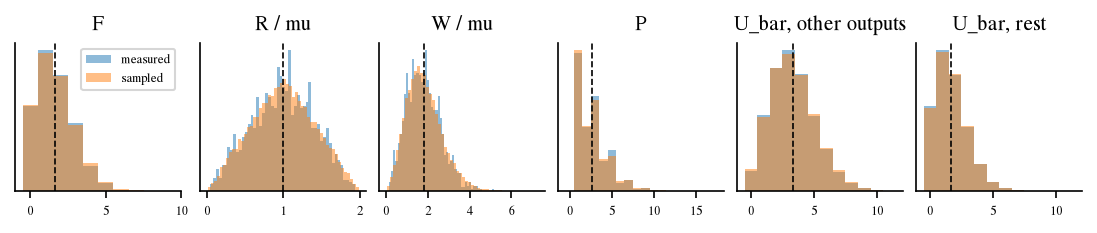

In [20]:
mu, ell = L, 2
measured = measure_variables(run.batch(32768, seed=1), mus=mu).select(ell=ell)
sampled = sample_variables(mu, ell, V, K, num_samples=20000, generator=torch.Generator().manual_seed(0))
expected = mean_variables(mu, ell, V, K)
print(f"{measured.num_rows} measured queries at mu={mu}, ell={ell}; {sampled.num_rows} samples")

panels = [("F", 1, "F"), ("R", mu, "R / mu"), ("W", mu, "W / mu"), ("P", 1, "P")]
fig, axes = create_fig(ncols=6, size='double', h=0.2, sharex=False)
for ax, (name, scale, title) in zip(axes, panels):
    data_measured, data_sampled = measured[name].numpy() / scale, sampled[name].numpy() / scale
    bins = np.arange(-0.5, max(data_measured.max(), data_sampled.max()) + 1.5) if scale == 1 else 50
    ax.hist(data_measured, bins=bins, density=True, alpha=0.5, label="measured")
    ax.hist(data_sampled, bins=bins, density=True, alpha=0.5, label="sampled")
    ax.axvline(expected[name].item() / scale, color="k", ls="--", lw=0.8)
    ax.set_title(title); ax.set_yticks([])
for ax, (columns, title) in zip(axes[4:], [(slice(0, K - 1), "U_bar, other outputs"), (slice(K - 1, None), "U_bar, rest")]):
    bins = np.arange(-0.5, 12.5)
    ax.hist(measured["U_bar"][:, columns].flatten().numpy(), bins=bins, density=True, alpha=0.5)
    ax.hist(sampled["U_bar"][:, columns].flatten().numpy(), bins=bins, density=True, alpha=0.5)
    ax.axvline(expected["U_bar"][0, columns].mean().item(), color="k", ls="--", lw=0.8)
    ax.set_title(title); ax.set_yticks([])
axes[0].legend()
plt.show()

**Poisson or multinomial counts.** For a single count the two laws agree. They differ in sums over many tokens: the counts share a budget of $\mu-2-2\ell$ keys, so their total fluctuates less than a sum of independent Poissons. The loss sums over many tokens through the logsumexp, which is why `EffectiveLoss` uses multinomial counts by default.

In [21]:
multinomial = sample_variables(mu, ell, V, K, num_samples=20000, counts="multinomial", generator=torch.Generator().manual_seed(0))
pd.DataFrame({source: {"mean of sum_b U_bar": table["U_bar"].sum(1).mean().item(),
                       "std of sum_b U_bar": table["U_bar"].sum(1).std().item(),
                       "mean U_bar (one rest token)": table["U_bar"][:, K].mean().item()}
              for source, table in (("measured", measured), ("poisson", sampled), ("multinomial", multinomial))}).round(3)

,measured,poisson,multinomial
mean of sum_b U_bar,208.745,210.685,208.646
std of sum_b U_bar,4.871,14.497,5.825
mean U_bar (one rest token),1.622,1.668,1.635


**Idea 2: sampled logit vectors.** `ansatz_logits(sample_variables(...), order_params, beta, L)` gives vectors $\bm h_\mu\in\mathbb R^V$ in the canonical layout, conditioned on $(\mu,\ell)$. Here the three levels are compared on the same cluster.

The sharp spikes in B and C are expected:
- at $\ell=0$, every trigger logit is the same single value;
- a token absent from the context has a logit of exactly 0.

The background in A turns them into peaks of finite width.

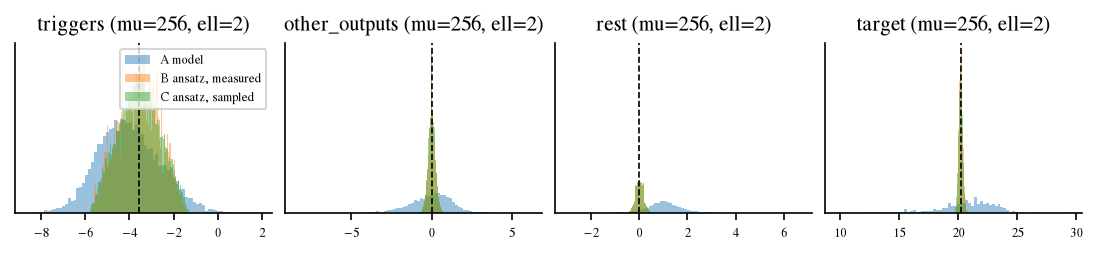

In [22]:
sampled_logits = ansatz_logits(sampled, order_params, beta, L)                   # C
measured_logits = ansatz_logits(measured, order_params, beta, L)                 # B
real_logits = model_table.select(mu=mu, ell=ell)["logits"]                       # A
mean_logits = ansatz_logits(expected, order_params, beta, L)[0]

fig, axes = create_fig(ncols=4, size='double', h=0.22, sharex=False)
for ax, block in zip(axes, ("triggers", "other_outputs", "rest", "target")):
    for label, values in (("A model", real_logits), ("B ansatz, measured", measured_logits), ("C ansatz, sampled", sampled_logits)):
        ax.hist(values[:, blocks[block]].flatten().numpy(), bins=80, density=True, alpha=0.45, label=label, histtype="stepfilled")
    ax.axvline(mean_logits[blocks[block]].mean().item(), color="k", ls="--", lw=0.8)
    ax.set_title(f"{block} (mu={mu}, ell={ell})"); ax.set_yticks([])
axes[0].legend()
plt.show()

**Several clusters at once.** Pass one $(\mu,\ell)$ per row as tensors. Wrap the logits in a `QueryTable` to use `select` / `groups` as on the real tables.

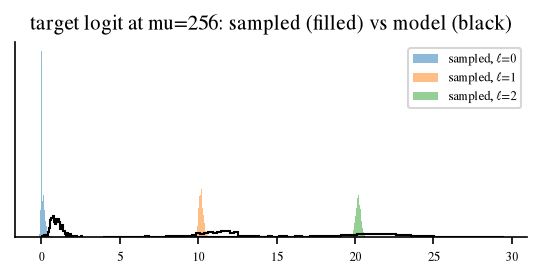

In [23]:
rows_mu = torch.full((30000,), L)
rows_ell = torch.tensor([0, 1, 2]).repeat_interleave(10000)
mixture = sample_variables(rows_mu, rows_ell, V, K, counts="multinomial", generator=torch.Generator().manual_seed(1))
mixture_table = QueryTable({"logits": ansatz_logits(mixture, order_params, beta, L), "mu": mixture["mu"], "ell": mixture["ell"], "K": K})

fig, axes = create_fig(size='single', h=0.5)
for (cluster_mu, cluster_ell), cluster in mixture_table.groups("mu", "ell"):
    axes.hist(cluster["logits"][:, -1].numpy(), bins=60, density=True, alpha=0.5, label=fr"sampled, $\ell$={cluster_ell}")
    real_cluster = model_table.select(mu=cluster_mu, ell=cluster_ell)["logits"][:, -1].numpy()
    axes.hist(real_cluster, bins=40, density=True, histtype="step", color="k")
axes.set_title(f"target logit at mu={L}: sampled (filled) vs model (black)"); axes.legend(); axes.set_yticks([])
plt.show()

## 6. Evaluation during training: the probes

`scripts/train.py` and `scripts/launcher.py` build an `Evaluator` from probes and call it on a fixed test batch.

- **The test batch is no longer filtered.** `preprocess_batch` only moves it to the device and reports what it holds, so `loss` estimates the population loss.
- **Positions are selected by trigger and $\ell$**, computed from the sequences.

The probes:

| Probe | Logs |
|---|---|
| `LossMetric(name=None, positions="all" \| "trigg" \| "non_trigg", ell=None \| k \| [k, ...] \| ">=k")` | Mean cross-entropy over a subset of positions. `ell` is only allowed with `"trigg"`. The default names are `loss`, `loss_trigg`, `loss_trigg_ell0`, `loss_trigg_ell_ge1`, … The value is NaN when no position matches, e.g. an `ell` absent from the batch. |
| `TopKAccuracy(k)`, `TargetProbMass()` | The in-context metrics, over trigger queries with $\ell\ge1$ only. `stop_at_accuracy` and the sweeps rely on these. |
| `OrderParameters()` | Every entry of `ORDER_PARAMS`, from `model.matrices()`. |
| `ComposedMatrices()`, `TriggerLogitTable(fractions)` | Artifacts: the matrices, and `logit_table` of the test batch at $\mu=\lceil fL\rceil$ (from `extra_args.logit_positions`). |

To log more losses during training, add them to the `scalars=[...]` list in `scripts/train.py`. Here the same machinery runs directly on the loaded model:

In [24]:
test_batch, stats = preprocess_batch(run.batch(2048, seed=2), device)
print(stats.summary())
evaluator = Evaluator(
    scalars=[LossMetric(), LossMetric(positions="trigg"), LossMetric(positions="non_trigg"),
             LossMetric(positions="trigg", ell=0), LossMetric(positions="trigg", ell=[1, 2]),
             LossMetric(positions="trigg", ell=">=1"), LossMetric("loss_rare", positions="trigg", ell=40),
             TopKAccuracy(1), TopKAccuracy(5), TargetProbMass(), OrderParameters()],
    artifacts=[ComposedMatrices(), TriggerLogitTable([0.5, 1.0])],
    chunk=512)
scalars_now = evaluator.scalars(model, test_batch, step=3000)
pd.Series(scalars_now).round(4)

test batch: 2048 sequences; trigger queries at 16.4% of positions, 8.4% with the trigger earlier in context


loss                   4.4269
loss_trigg             2.2590
loss_non_trigg         4.8526
loss_trigg_ell0        4.6481
loss_trigg_ell1_2      0.0024
loss_trigg_ell_ge1     0.0021
loss_rare                 NaN
top1_accuracy          1.0000
top5_accuracy          1.0000
target_prob            0.9979
M_on                 -14.3582
M_off                  0.0779
Q_on                 -44.5287
Q_T                   -0.8628
G_on                  16.4387
G_T                   -2.6555
dtype: float64

In [25]:
artifacts_now = evaluator.artifacts(model, test_batch, step=3000)       # what log_artifacts would write
for (name, group), (data, atype) in artifacts_now.items():
    print(f"{group}/{name}_step_3000 ({atype}):", {key: getattr(value, 'shape', value) for key, value in data.items()})

saved_table = run.logit_table("last")                                   # the run's own probe output
print("saved during training:", saved_table.num_rows, "rows at mu =", sorted(set(saved_table["mu"].tolist())),
      "| ell present:", sorted(set(saved_table["ell"].tolist())))

matrices/matrices_step_3000 (pickle): {'M': (256, 256), 'Q': (128, 128), 'G': (128, 128)}
logits/table_step_3000 (pickle): {'logits': (670, 128), 'mu': (670,), 'ell': (670,), 'sequence_index': (670,), 'K': 25}
saved during training: 250 rows at mu = [128, 192, 256] | ell present: [0, 1, 2, 3, 4, 7]


## 7. The effective population loss (idea 4)

$$
\mathcal L^{\rm eff}=(1-q_T)\log V+q_T\;\underset{\mu}{\rm mean}\sum_\ell \text{Poisson}(\ell;p_T\mu)\,\text{CE}(\mu,\ell),\qquad q_T=\tfrac K{V+K},
$$
with $\text{CE}(\mu,\ell)=\mathbb E[\text{logsumexp}(\bm h)-h_{\rm target}]$ under the ansatz. This is the manuscript's loss decomposition with $\ell=0$ kept explicitly; it no longer goes into $\mathcal L^\infty$.

`EffectiveLoss(V, L, K, beta, method, mus=None, num_samples=256, counts="multinomial", ell_tol=1e-6, seed=0, device=None)`, or `EffectiveLoss.from_config(run.config, ...)`:

| Option | Effect |
|---|---|
| `method="mean"` | CE at the mean logit vector. Deterministic and cheap. |
| `method="mc"` | CE averaged over `num_samples` sampled vectors per $(\mu,\ell)$. The samples are drawn **once** in the constructor (common random numbers), so the loss is a smooth function of the parameters. |
| `mus` | The positions averaged over: all $1..L$ by default, or a subset (a quadrature), to save memory for `mc`. |
| `ell_tol` | Where the Poisson tail is cut; the kept probabilities are renormalised. |

Calling the object on a dict gives a differentiable 0-d tensor. A missing parameter counts as 0.
- `value_and_grad(order_params)` returns $(\mathcal L,\{\partial\mathcal L/\partial\theta_i\})$ for every registered parameter.
- `breakdown(order_params)` returns the parts and a per-cluster table.
- `trigger_loss(clusters, ell)` is the analogue of `LossMetric(positions="trigg", ell=...)`.

In [26]:
mean_loss = EffectiveLoss.from_config(config, method="mean", device=device)
mc_loss = EffectiveLoss.from_config(config, method="mc", mus=range(16, L + 1, 16), num_samples=256, device=device)

value, gradient = mc_loss.value_and_grad(order_params)
parts = mean_loss.breakdown(order_params)
pd.DataFrame({
    "effective (mean)": {"loss": parts["loss"], "loss_trigg": parts["loss_trigg"], "loss_non_trigg": parts["loss_non_trigg"],
                         "loss_trigg_ell0": trigger_loss(parts["clusters"], 0), "loss_trigg_ell_ge1": trigger_loss(parts["clusters"], ">=1")},
    "logged / measured": {key: scalars_now[key] for key in ("loss", "loss_trigg", "loss_non_trigg", "loss_trigg_ell0", "loss_trigg_ell_ge1")},
}).round(4)

,effective (mean),logged / measured
loss,4.4318,4.4269
loss_trigg,2.2802,2.2590
loss_non_trigg,4.8520,4.8526
loss_trigg_ell0,4.7095,4.6481
loss_trigg_ell_ge1,0.0023,0.0021


In [27]:
print("mc loss:", round(value, 4))
pd.Series(gradient, name="d loss / d order parameter (mc)")

mc loss: 4.4137


M_on     0.000259
M_off    0.002477
Q_on     0.000046
Q_T      0.001700
G_on     0.000026
G_T      0.001490
Name: d loss / d order parameter (mc), dtype: float64

**Per cluster.** The CE at $\mu=L$ for each $\ell$, from four sources:
- the trained model (A);
- the network on the exact ansatz matrices (B);
- the effective loss, mean and MC.

The empirical $\ell$ frequencies are shown against the Poisson weights.

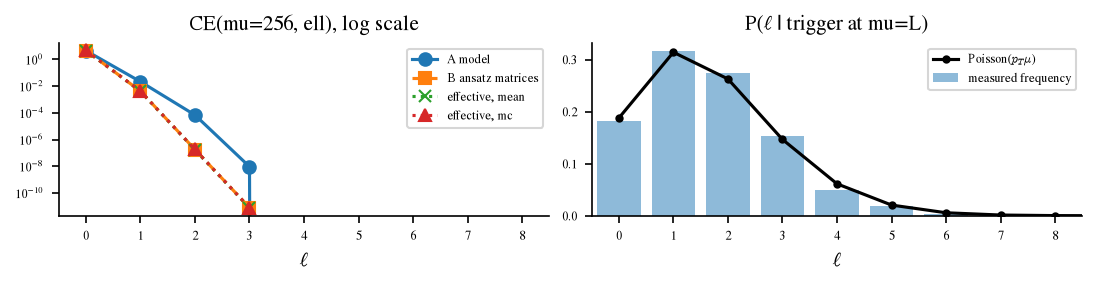

In [28]:
effective_mean = as_frame(parts["clusters"])
effective_mc = as_frame(mc_loss.breakdown(order_params)["clusters"])
exact_clusters = as_frame(cluster_cross_entropy(QueryTable({"logits": network_on_ansatz, "mu": variables["mu"], "ell": variables["ell"]})))
real_clusters = as_frame(model_clusters)

fig, axes = create_fig(ncols=2, size='double', h=0.25, sharex=True)
for label, frame, style in (("A model", real_clusters, "o-"), ("B ansatz matrices", exact_clusters, "s--"),
                            ("effective, mean", effective_mean, "x:"), ("effective, mc", effective_mc, "^:")):
    at_last = frame[(frame["mu"] == L) & (frame["ell"] <= 6)]
    axes[0].plot(at_last["ell"], at_last["cross_entropy"], style, label=label)
axes[0].set_yscale("log"); axes[0].set_xlabel(r"$\ell$"); axes[0].set_title(f"CE(mu={L}, ell), log scale"); axes[0].legend()
observed = real_clusters[real_clusters["mu"] == L]
axes[1].bar(observed["ell"], observed["count"] / observed["count"].sum(), alpha=0.5, label="measured frequency")
poisson_weights = effective_mean[effective_mean["mu"] == L]
axes[1].plot(poisson_weights["ell"], poisson_weights["probability"], "k.-", label=r"Poisson($p_T\mu$)")
axes[1].set_xlim(-0.5, 8.5); axes[1].set_xlabel(r"$\ell$"); axes[1].set_title(r"P($\ell$ | trigger at mu=L)"); axes[1].legend()
plt.show()

**Static check over training.** Plug the *logged* order parameters at every evaluation step into the effective loss, and compare with the logged loss. No dynamics is involved: this tests the loss model on its own.

The second curve keeps only $M^{on},Q^{on},\Gamma^{on}$, i.e. the manuscript's closure (the other parameters are left out of the dict, so they count as 0).

,logged loss,"effective, extended ansatz","effective, signal only"
step,,,
0,4.8567,4.8520,4.8520
429,4.8525,4.8520,4.8520
857,4.8522,4.8520,4.8520
1286,4.8521,4.8520,4.8520
1714,4.8513,4.8516,4.8520
2143,4.4366,4.4359,4.4436
2571,4.4336,4.4332,4.4431
3000,4.4321,4.4318,4.4431


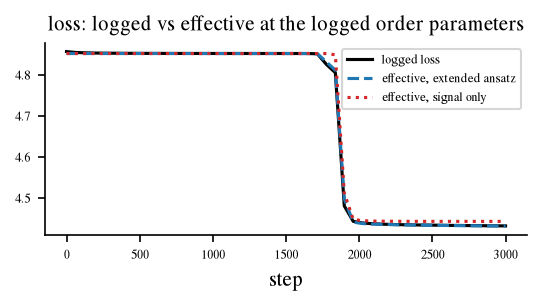

In [29]:
signal_names = ("M_on", "Q_on", "G_on")
static = pd.DataFrame({
    "logged loss": metrics["loss"],
    "effective, extended ansatz": [mean_loss({name: row[name] for name in ORDER_PARAMS}).item() for _, row in metrics.iterrows()],
    "effective, signal only": [mean_loss({name: row[name] for name in signal_names}).item() for _, row in metrics.iterrows()],
}, index=metrics.index)

fig, axes = create_fig(size='single', h=0.55)
for column, style in zip(static.columns, ("k-", "C0--", "C3:")):
    axes.plot(static.index, static[column], style, label=column)
axes.set_xlabel("step"); axes.set_title("loss: logged vs effective at the logged order parameters"); axes.legend()
static.iloc[::7].round(4)

## 8. The effective dynamics (idea 5): `integrate`

`integrate(loss, initial_order_params, rates, steps, record_steps=None, method="LSODA", rtol=1e-6, atol=1e-9, **solver_options)` integrates
$$
\frac{d\theta_i}{d\,\text{step}}=-\,\text{rates}_i\,\frac{\partial\mathcal L}{\partial\theta_i}
$$
with `scipy.integrate.solve_ivp`, with time counted in SGD steps.

- **`loss`** is any callable `{name: tensor} -> tensor`. Gradients come from autograd, so any extension of the ansatz works unchanged.
- **Freezing:** a parameter that is not in `rates` keeps its initial value, and one that is also missing from `initial_order_params` stays at 0.
- **Output:** a DataFrame indexed by `step`, with the metric names and `loss`, so it overlays directly on `run.metrics`.
- **Starting point:** all parameters at 0 is a fixed point, so start from `run.order_params("first")`.
- **Solver:** `LSODA` switches to a stiff solver when needed. If the solver stops early you get a warning and the rows reached so far.

> ⚠️ **Placeholder rates.** The rates must come from your derivation of the projected gradient flow: the Jacobian of the projection, $\eta_0$, $\sigma_0^2$, finite-$d$ corrections. The cell below uses the naive guess $\text{rate}_i=\alpha_{lr}/n_i$, with $n_i$ from `support_sizes`, only to make the example run. **Replace this one line with your rates.**

In [30]:
sizes = support_sizes(L, V, K)
rates = {name: config.optim_args.alpha_lr / size for name, size in sizes.items()}     # PLACEHOLDER: replace with the derived rates
pd.Series(rates, name="rate per SGD step (placeholder)")

M_on      11.764706
M_off      0.092635
Q_on     120.000000
Q_T        0.944882
G_on      29.126214
G_T        0.937500
Name: rate per SGD step (placeholder), dtype: float64

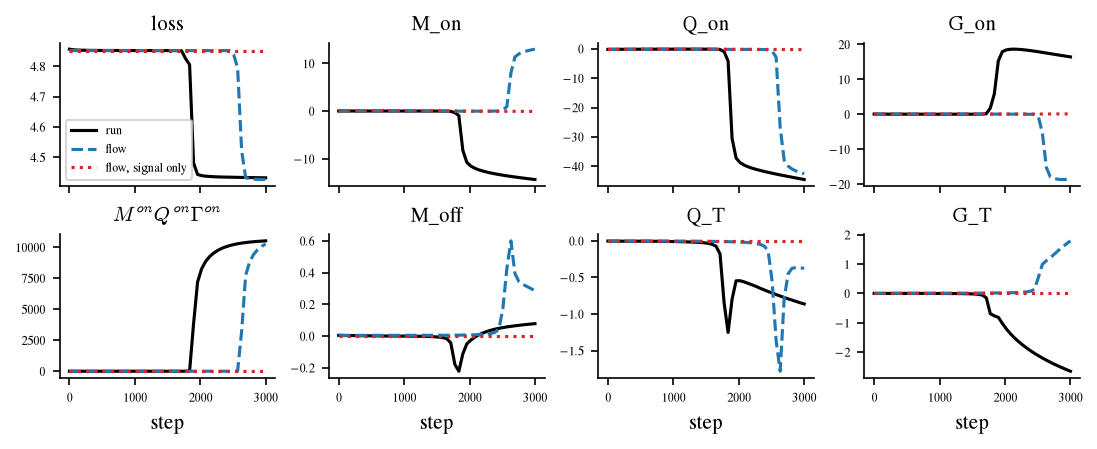

In [31]:
flow_loss = EffectiveLoss.from_config(config, method="mean", mus=range(8, L + 1, 8), device=device)
start = run.order_params("first")
flow = integrate(flow_loss, start, rates, steps=metrics.index.max(), record_steps=metrics.index)

signal_start = {name: start[name] for name in signal_names}                 # the manuscript's closure:
signal_flow = integrate(flow_loss, signal_start, {name: rates[name] for name in signal_names},
                        steps=metrics.index.max(), record_steps=metrics.index)   # others absent -> 0, frozen

fig, axes = create_fig(nrows=2, ncols=4, size='double', h=0.4, sharex=True)
panels = ["loss", "M_on", "Q_on", "G_on", "product", "M_off", "Q_T", "G_T"]
for ax, name in zip(axes.flatten(), panels):
    if name == "product":
        series = {source: frame["M_on"] * frame["Q_on"] * frame["G_on"] for source, frame in
                  (("run", metrics), ("flow", flow), ("flow, signal only", signal_flow))}
        ax.set_title(r"$M^{on}Q^{on}\Gamma^{on}$")
    else:
        series = {"run": metrics[name], "flow": flow[name], "flow, signal only": signal_flow[name]}
        ax.set_title(name)
    for (source, values), style in zip(series.items(), ("k-", "C0--", "C3:")):
        ax.plot(values.index, values, style, label=source)
for ax in axes[1]:
    ax.set_xlabel("step")
axes[0, 0].legend()
plt.show()

**Escape times.** The flow can take longer than the run to leave the plateau, so integrate further and measure when each curve crosses the midpoint between $\log V$ and its final loss:

In [32]:
def escape_step(loss_curve):
    midpoint = (np.log(V) + loss_curve.min()) / 2
    below = loss_curve.index[loss_curve < midpoint]
    return below[0] if len(below) else np.nan

horizon = 4 * metrics.index.max()
long_flow = integrate(flow_loss, start, rates, steps=horizon, record_steps=np.linspace(0, horizon, 801))
long_signal_flow = integrate(flow_loss, signal_start, {name: rates[name] for name in signal_names},
                             steps=horizon, record_steps=np.linspace(0, horizon, 801))
pd.DataFrame({
    "escape step": {"run": escape_step(metrics["loss"]), "flow, extended ansatz": escape_step(long_flow["loss"]),
                    "flow, signal only": escape_step(long_signal_flow["loss"])},
    "final loss": {"run": metrics["loss"].iloc[-1], "flow, extended ansatz": long_flow["loss"].iloc[-1],
                   "flow, signal only": long_signal_flow["loss"].iloc[-1]},
    "final M_on Q_on G_on": {source: (frame["M_on"] * frame["Q_on"] * frame["G_on"]).iloc[-1]
                             for source, frame in (("run", metrics), ("flow, extended ansatz", long_flow),
                                                   ("flow, signal only", long_signal_flow))},
}).round(3)

,escape step,final loss,final M_on Q_on G_on
run,1898.0,4.432,10510.166
"flow, extended ansatz",2625.0,4.419,11280.949
"flow, signal only",4515.0,4.434,14546.353


**Reading the figure.**
- **The plateau and the escape are reproduced** even with the placeholder rates. How well the escape steps in the table match is the quantitative test of your rates.
- **The signal-only flow** (the manuscript's closure, everything else frozen at 0) also escapes, but later. Within the run's 3000 steps it may still look flat. Comparing the two escape steps shows how much $M^{off},Q^T,\Gamma^T$ speed up the transition under the same rates.
- **The signs.** $M^{on}$ and $\Gamma^{on}$ can end with opposite signs to the run while their product with $Q^{on}$ keeps its sign. The logits are invariant under that sign change, so this is a symmetry and not an error; the "product" panel shows the invariant combination.
- **Settings to try:**
  - `method="mc"` in `flow_loss`, to include the logit spread of the ansatz;
  - a different `mus`, to trade accuracy for speed;
  - `record_steps`, to choose the reporting times;
  - `method="Radau"` or `"RK45"` in `integrate`, and `rtol` / `atol`.

## 9. Extending the ansatz

To add an order parameter, for example a $Q^{TT}$ for the trigger columns of the trigger rows of $Q$, the diagnosis in Section 4 suggests:

1. **`theory/ansatz.py`:** register it in `ORDER_PARAMS` with its matrix and support. Adjust the supports of overlapping parameters, here $Q^T$, so that they stay disjoint.
2. **`theory/ansatz.py`:** add its terms to `ansatz_logits`.
3. **`theory/variables.py`:** if those terms need a new sequence variable (here the occurrences of the other triggers), add it to `measure_variables`, `sample_variables` and `mean_variables`.
4. **Run `pytest`.** `tests/test_theory.py` must still match the network to 1e-12. Add the new variable's moments to `tests/test_sampler.py`.

Nothing else changes. `OrderParameters`, `run.order_params`, `ansatz_matrices`, `support_sizes`, `EffectiveLoss` and `integrate` all read the registry.

Step 1 alone is enough to *measure* a new parameter, even from runs made before it existed. This is done here temporarily and undone right after:

In [33]:
def trigger_columns_off_diagonal(L, V, K):             # Q_{ac}: a, c both triggers, c != a
    is_trigger = torch.arange(V) < K
    return is_trigger[:, None] & is_trigger[None, :] & ~torch.eye(V, dtype=torch.bool)

ORDER_PARAMS["Q_TT"] = ("Q", trigger_columns_off_diagonal)
try:
    print("support size:", support_sizes(L, V, K)["Q_TT"])
    print("Q_TT over training:", {step: round(run.order_params(step)["Q_TT"], 3) for step in run.steps("matrices")[::3]})
    print("Q_T  over training:", {step: round(run.order_params(step)["Q_T"], 3) for step in run.steps("matrices")[::3]})
finally:
    del ORDER_PARAMS["Q_TT"]                            # back to the six parameters of the ansatz
print(list(ORDER_PARAMS))

support size: 600
Q_TT over training: {0: 0.005, 1000: 0.001, 2000: 0.84, 3000: 2.031}
Q_T  over training: {0: -0.003, 1000: -0.009, 2000: -0.542, 3000: -0.863}
['M_on', 'M_off', 'Q_on', 'Q_T', 'G_on', 'G_T']


---
**Where to look next**

| What | Where |
|---|---|
| The derivation | `paper/scratch/extended_ansatz.tex` |
| The architecture summary | the code repo's `CLAUDE.md` |
| Usage examples you can run | the tests: `tests/test_theory.py`, `test_sampler.py`, `test_effective_loss.py`, `test_flow.py` |